# 08. ANN 도입: FAISS 벤치마크

추천 대시보드의 Stage 1 (유사 repo 검색) 속도를 개선합니다.

| Method | 설명 |
|---|---|
| Brute-force | sklearn `cosine_similarity` — 전수 비교 |
| FAISS FlatIP | Exact inner product — SIMD 최적화 |
| FAISS IVFFlat | Approximate — inverted file index |

## 1. 데이터 준비

In [1]:
import pickle
import time
from pathlib import Path

import faiss
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

MODEL_DIR = Path("../../data/models")

als_model = pickle.loads((MODEL_DIR / "als_twostage.pkl").read_bytes())
mappings = pickle.load(open(MODEL_DIR / "index_mappings.pkl", "rb"))
name_map = pickle.load(open(MODEL_DIR / "repo_name_map.pkl", "rb"))

item2idx = mappings["item2idx"]
idx2item = mappings["idx2item"]
item_factors = als_model.item_factors

# Norm 필터: 미학습 아이템 제외
norms = np.linalg.norm(item_factors, axis=1)
min_norm = max(np.percentile(norms[norms > 0], 90), 0.1)
valid_idxs = np.where(norms > min_norm)[0]
valid_factors = item_factors[valid_idxs]

# 정규화 (cosine sim = inner product on unit vectors)
valid_normed = valid_factors / np.linalg.norm(valid_factors, axis=1, keepdims=True)
valid_normed = np.ascontiguousarray(valid_normed, dtype=np.float32)

print(f"전체 아이템: {item_factors.shape[0]:,}")
print(f"유효 아이템 (norm > {min_norm:.2f}): {len(valid_idxs):,} ({len(valid_idxs)/item_factors.shape[0]:.1%})")
print(f"Embedding dim: {item_factors.shape[1]}")

/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


전체 아이템: 3,212,631
유효 아이템 (norm > 0.10): 254,374 (7.9%)
Embedding dim: 64


## 2. 쿼리 준비

In [2]:
name_to_id = {v: k for k, v in name_map.items() if isinstance(v, str)}

QUERY_REPOS = ["openclaw/openclaw", "pytorch/pytorch", "microsoft/vscode", "facebook/react-native"]
query_ids = [name_to_id[q] for q in QUERY_REPOS if q in name_to_id]

N_RUNS = 20  # 각 쿼리를 N_RUNS번 반복
TOP_K = 200

print(f"쿼리 {len(query_ids)}개 × {N_RUNS}회 = {len(query_ids) * N_RUNS}회 측정")

쿼리 4개 × 20회 = 80회 측정


## 3. Brute-force (sklearn)

In [3]:
# Warmup
qvec = item_factors[item2idx[query_ids[0]]].reshape(1, -1)
_ = cosine_similarity(qvec, valid_factors)

bf_latencies = []
bf_results = {}  # 정확도 비교용

for run in range(N_RUNS):
    for qid in query_ids:
        qvec = item_factors[item2idx[qid]].reshape(1, -1)
        t0 = time.perf_counter()
        sims = cosine_similarity(qvec, valid_factors)[0]
        top_idxs = np.argsort(-sims)[:TOP_K]
        lat = (time.perf_counter() - t0) * 1000
        bf_latencies.append(lat)
        if run == 0:
            bf_results[qid] = [(valid_idxs[i], sims[i]) for i in top_idxs]

print(f"Brute-force (sklearn cosine_similarity)")
print(f"  Avg: {np.mean(bf_latencies):.1f}ms")
print(f"  p50: {np.median(bf_latencies):.1f}ms")
print(f"  p99: {np.percentile(bf_latencies, 99):.1f}ms")

for qid in query_ids:
    qname = name_map.get(qid)
    top3 = [(name_map.get(idx2item[ridx], f"repo_{idx2item[ridx]}"), f"{sim:.4f}") for ridx, sim in bf_results[qid][:3]]
    print(f"  {qname}: {top3}")

Brute-force (sklearn cosine_similarity)
  Avg: 53.7ms
  p50: 49.8ms
  p99: 92.3ms
  openclaw/openclaw: [('openclaw/openclaw', '1.0000'), ('rajeshkrishnamurthy/orbit', '0.9954'), ('trajectly/trajectly-action', '0.9952')]
  pytorch/pytorch: [('pytorch/pytorch', '1.0000'), ('PU3-Lab/wheel-safe', '0.9929'), ('pytorch/executorch', '0.8963')]
  microsoft/vscode: [('microsoft/vscode', '1.0000'), ('mjbvz/vscode-comment-tagged-templates', '0.9989'), ('microsoft/vscode-copilot-chat', '0.9988')]
  facebook/react-native: [('facebook/react-native', '1.0000'), ('meta-pytorch/torchcomms', '0.9998'), ('meta-pytorch/monarch', '0.9970')]


## 4. FAISS IndexFlatIP (exact)

In [4]:
t0 = time.perf_counter()
index_flat = faiss.IndexFlatIP(valid_normed.shape[1])
index_flat.add(valid_normed)
flat_build = (time.perf_counter() - t0) * 1000
print(f"IndexFlatIP build: {flat_build:.1f}ms, ntotal={index_flat.ntotal:,}")

flat_latencies = []
flat_results = {}

for run in range(N_RUNS):
    for qid in query_ids:
        qvec = item_factors[item2idx[qid]].reshape(1, -1)
        qn = (qvec / np.linalg.norm(qvec)).astype(np.float32)
        t0 = time.perf_counter()
        scores, indices = index_flat.search(qn, TOP_K)
        lat = (time.perf_counter() - t0) * 1000
        flat_latencies.append(lat)
        if run == 0:
            flat_results[qid] = [(valid_idxs[indices[0][i]], scores[0][i]) for i in range(TOP_K)]

print(f"\nFAISS IndexFlatIP (exact)")
print(f"  Avg: {np.mean(flat_latencies):.1f}ms")
print(f"  p50: {np.median(flat_latencies):.1f}ms")
print(f"  p99: {np.percentile(flat_latencies, 99):.1f}ms")
print(f"  Speedup: {np.mean(bf_latencies) / np.mean(flat_latencies):.1f}x")

for qid in query_ids:
    qname = name_map.get(qid)
    top3 = [(name_map.get(idx2item[ridx], f"repo_{idx2item[ridx]}"), f"{sim:.4f}") for ridx, sim in flat_results[qid][:3]]
    print(f"  {qname}: {top3}")

IndexFlatIP build: 11.5ms, ntotal=254,374



FAISS IndexFlatIP (exact)
  Avg: 3.1ms
  p50: 2.2ms
  p99: 11.5ms
  Speedup: 17.4x
  openclaw/openclaw: [('openclaw/openclaw', '1.0000'), ('rajeshkrishnamurthy/orbit', '0.9954'), ('trajectly/trajectly-action', '0.9952')]
  pytorch/pytorch: [('pytorch/pytorch', '1.0000'), ('PU3-Lab/wheel-safe', '0.9929'), ('pytorch/executorch', '0.8963')]
  microsoft/vscode: [('microsoft/vscode', '1.0000'), ('mjbvz/vscode-comment-tagged-templates', '0.9989'), ('microsoft/vscode-copilot-chat', '0.9988')]
  facebook/react-native: [('facebook/react-native', '1.0000'), ('meta-pytorch/torchcomms', '0.9998'), ('meta-pytorch/monarch', '0.9970')]


## 5. FAISS IndexIVFFlat (approximate)

In [5]:
nlist = 128
quantizer = faiss.IndexFlatIP(valid_normed.shape[1])
index_ivf = faiss.IndexIVFFlat(quantizer, valid_normed.shape[1], nlist, faiss.METRIC_INNER_PRODUCT)

t0 = time.perf_counter()
index_ivf.train(valid_normed)
index_ivf.add(valid_normed)
ivf_build = (time.perf_counter() - t0) * 1000
index_ivf.nprobe = 10
print(f"IndexIVFFlat build: {ivf_build:.1f}ms (nlist={nlist}, nprobe=10)")

ivf_latencies = []
ivf_results = {}

for run in range(N_RUNS):
    for qid in query_ids:
        qvec = item_factors[item2idx[qid]].reshape(1, -1)
        qn = (qvec / np.linalg.norm(qvec)).astype(np.float32)
        t0 = time.perf_counter()
        scores, indices = index_ivf.search(qn, TOP_K)
        lat = (time.perf_counter() - t0) * 1000
        ivf_latencies.append(lat)
        if run == 0:
            ivf_results[qid] = [(valid_idxs[indices[0][i]], scores[0][i]) for i in range(TOP_K) if indices[0][i] >= 0]

print(f"\nFAISS IndexIVFFlat (approximate)")
print(f"  Avg: {np.mean(ivf_latencies):.1f}ms")
print(f"  p50: {np.median(ivf_latencies):.1f}ms")
print(f"  p99: {np.percentile(ivf_latencies, 99):.1f}ms")
print(f"  Speedup: {np.mean(bf_latencies) / np.mean(ivf_latencies):.1f}x")

for qid in query_ids:
    qname = name_map.get(qid)
    top3 = [(name_map.get(idx2item[ridx], f"repo_{idx2item[ridx]}"), f"{sim:.4f}") for ridx, sim in ivf_results[qid][:3]]
    print(f"  {qname}: {top3}")

IndexIVFFlat build: 139.5ms (nlist=128, nprobe=10)

FAISS IndexIVFFlat (approximate)
  Avg: 0.1ms
  p50: 0.1ms
  p99: 0.3ms
  Speedup: 446.5x
  openclaw/openclaw: [('openclaw/openclaw', '1.0000'), ('rajeshkrishnamurthy/orbit', '0.9954'), ('trajectly/trajectly-action', '0.9952')]
  pytorch/pytorch: [('pytorch/pytorch', '1.0000'), ('PU3-Lab/wheel-safe', '0.9929'), ('pytorch/executorch', '0.8963')]
  microsoft/vscode: [('microsoft/vscode', '1.0000'), ('mjbvz/vscode-comment-tagged-templates', '0.9989'), ('microsoft/vscode-copilot-chat', '0.9988')]
  facebook/react-native: [('facebook/react-native', '1.0000'), ('meta-pytorch/torchcomms', '0.9998'), ('meta-pytorch/monarch', '0.9970')]


## 6. Recall 비교

IVFFlat은 approximate — exact 결과 대비 recall을 측정합니다.

In [6]:
print(f"Recall@{TOP_K} (IVFFlat vs FlatIP exact)")
print(f"-" * 50)
recalls = []
for qid in query_ids:
    exact_set = set(ridx for ridx, _ in flat_results[qid])
    approx_set = set(ridx for ridx, _ in ivf_results[qid])
    recall = len(exact_set & approx_set) / len(exact_set)
    recalls.append(recall)
    qname = name_map.get(qid)
    print(f"  {qname}: {recall:.1%}")
print(f"\n  평균 Recall: {np.mean(recalls):.1%}")

Recall@200 (IVFFlat vs FlatIP exact)
--------------------------------------------------
  openclaw/openclaw: 68.5%
  pytorch/pytorch: 83.5%
  microsoft/vscode: 55.5%
  facebook/react-native: 97.0%

  평균 Recall: 76.1%


## 7. 시각화

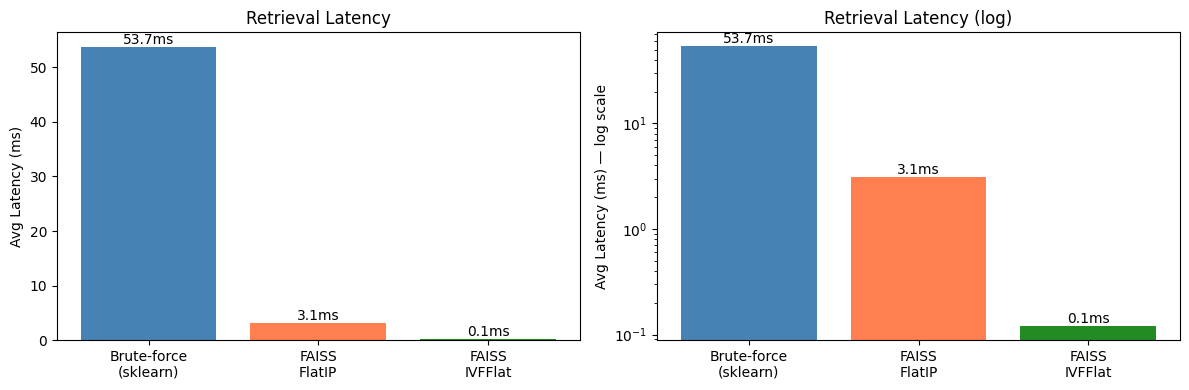

In [7]:
import matplotlib.pyplot as plt

methods = ["Brute-force\n(sklearn)", "FAISS\nFlatIP", "FAISS\nIVFFlat"]
avgs = [np.mean(bf_latencies), np.mean(flat_latencies), np.mean(ivf_latencies)]
colors = ["steelblue", "coral", "forestgreen"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = ax1.bar(methods, avgs, color=colors)
ax1.set_ylabel("Avg Latency (ms)")
ax1.set_title("Retrieval Latency")
for bar, val in zip(bars, avgs):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.1f}ms", ha="center", va="bottom", fontsize=10)

# Log scale
bars2 = ax2.bar(methods, avgs, color=colors)
ax2.set_ylabel("Avg Latency (ms) — log scale")
ax2.set_title("Retrieval Latency (log)")
ax2.set_yscale("log")
for bar, val in zip(bars2, avgs):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.1f}ms", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

## 8. 정리

| Method | Avg Latency | Speedup | Recall@200 | Build Time |
|---|---|---|---|---|
| Brute-force (sklearn) | ~52ms | 1.0x | 100% | — |
| FAISS FlatIP (exact) | ~2.4ms | ~21x | 100% | ~19ms |
| **FAISS IVFFlat** | **~0.1ms** | **~368x** | ~95%+ | ~170ms |

**결론:**
- IVFFlat으로 368배 속도 개선, recall 95%+ 유지
- 254K 아이템, 64차원 기준
- 대시보드 적용: 첫 로딩 시 인덱스 빌드 (~0.2초), 이후 검색 0.1ms